# ⚽ Football Match Prediction — Step 2: Exploratory Data Analysis (EDA)

**Dataset:** `matches_all_leagues.csv` — 5,320 matches, English Premier League + Spanish La Liga, seasons 2018/19 → 2024/25.

**Goal of this notebook:** understand the data before modeling — outcome balance, home advantage, what xG tells us, what the bookmaker odds encode, and **how the two leagues differ in predictability**. Every chart is shown overall *and* split by league so we can later explain why a model might score higher on one league than the other.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

LEAGUE_LABEL = {"epl": "Premier League", "laliga": "La Liga"}
RESULT_LABEL = {"H": "Home Win", "D": "Draw", "A": "Away Win"}

In [2]:
df = pd.read_csv("../data/processed/matches_all_leagues.csv", dtype={"Season": str})
df["Date"] = pd.to_datetime(df["Date"])
df["LeagueName"] = df["League"].map(LEAGUE_LABEL)
print(df.shape)
df.head()

(6080, 50)


,League,Div,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,B365H,B365D,B365A,PSH,PSD,PSA,PSCH,PSCD,PSCA,WHH,WHD,WHA,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,home_xG,away_xG,p_home,p_draw,p_away,understat_id,LeagueName
0,epl,E0,1819,2018-08-10,Man United,Leicester,2,1,H,1,0,H,8,13,6,4,2,5,11,8,2,1,0,0,1.57,3.9,7.50,1.58,3.93,7.50,1.55,4.07,7.69,1.57,3.8,6.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.513700,1.73813,0.2812,0.3275,0.3913,9197,Premier League
1,epl,E0,1819,2018-08-11,Bournemouth,Cardiff,2,0,H,1,0,H,12,10,4,1,7,4,11,9,1,1,0,0,1.90,3.6,4.50,1.89,3.63,4.58,1.88,3.61,4.70,1.91,3.5,4.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.600220,1.50693,0.6773,0.2104,0.1123,9202,Premier League
2,epl,E0,1819,2018-08-11,Fulham,Crystal Palace,0,2,A,0,1,A,15,10,6,9,5,5,9,11,1,2,0,0,2.50,3.4,3.00,2.50,3.46,3.00,2.62,3.38,2.90,2.45,3.3,2.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.638076,1.07816,0.2004,0.3242,0.4754,9201,Premier League
3,epl,E0,1819,2018-08-11,Huddersfield,Chelsea,0,3,A,0,2,A,6,13,1,4,2,5,9,8,2,1,0,0,6.50,4.0,1.61,6.41,4.02,1.62,7.24,3.95,1.58,5.80,3.9,1.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.396115,2.31427,0.0214,0.1011,0.8775,9200,Premier League
4,epl,E0,1819,2018-08-11,Newcastle,Tottenham,1,2,A,1,2,A,15,15,2,5,3,5,11,12,2,2,0,0,3.90,3.5,2.04,3.83,3.57,2.08,4.74,3.53,1.89,3.80,3.2,2.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.974497,2.58097,0.0800,0.1479,0.7721,9198,Premier League


## 2. Dataset Overview

In [3]:
print("Rows x Cols:", df.shape)
print("\nMatches per league:")
print(df["League"].value_counts())
print("\nSeasons:", sorted(df["Season"].unique()))
print("\nDate range:", df["Date"].min().date(), "->", df["Date"].max().date())

Rows x Cols: (6080, 50)

Matches per league:
League
epl       3040
laliga    3040
Name: count, dtype: int64

Seasons: ['1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526']

Date range: 2018-08-10 -> 2026-05-24


In [4]:
# Column groups
print("Columns:\n")
for c in df.columns:
    print(f"  {c:12s} {df[c].dtype}")

Columns:

  League       object
  Div          object
  Season       object
  Date         datetime64[ns]
  HomeTeam     object
  AwayTeam     object
  FTHG         int64
  FTAG         int64
  FTR          object
  HTHG         int64
  HTAG         int64
  HTR          object
  HS           int64
  AS           int64
  HST          int64
  AST          int64
  HC           int64
  AC           int64
  HF           int64
  AF           int64
  HY           int64
  AY           int64
  HR           int64
  AR           int64
  B365H        float64
  B365D        float64
  B365A        float64
  PSH          float64
  PSD          float64
  PSA          float64
  PSCH         float64
  PSCD         float64
  PSCA         float64
  WHH          float64
  WHD          float64
  WHA          float64
  Time         object
  MaxH         float64
  MaxD         float64
  MaxA         float64
  AvgH         float64
  AvgD         float64
  AvgA         float64
  home_xG      float64
  away_xG  

### Missing values
We expect a few gaps (oldest season lacks consensus-odds columns, William Hill missing for some fixtures). The core columns — result, goals, shots, xG, Bet365 & Pinnacle odds — are complete.

In [5]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
pd.DataFrame({"missing": miss, "pct": miss_pct})

,missing,pct
Div,1900,31.2
WHH,952,15.7
WHD,952,15.7
WHA,952,15.7
AvgH,760,12.5
MaxD,760,12.5
MaxH,760,12.5
Time,760,12.5
MaxA,760,12.5
AvgD,760,12.5


## 3. Target Variable — Match Result (FTR)

`FTR` is what we predict: **H** (home win), **D** (draw), **A** (away win). The class balance matters a lot — if draws are rare, accuracy alone will be misleading, and the Draw class will be the hardest to predict.

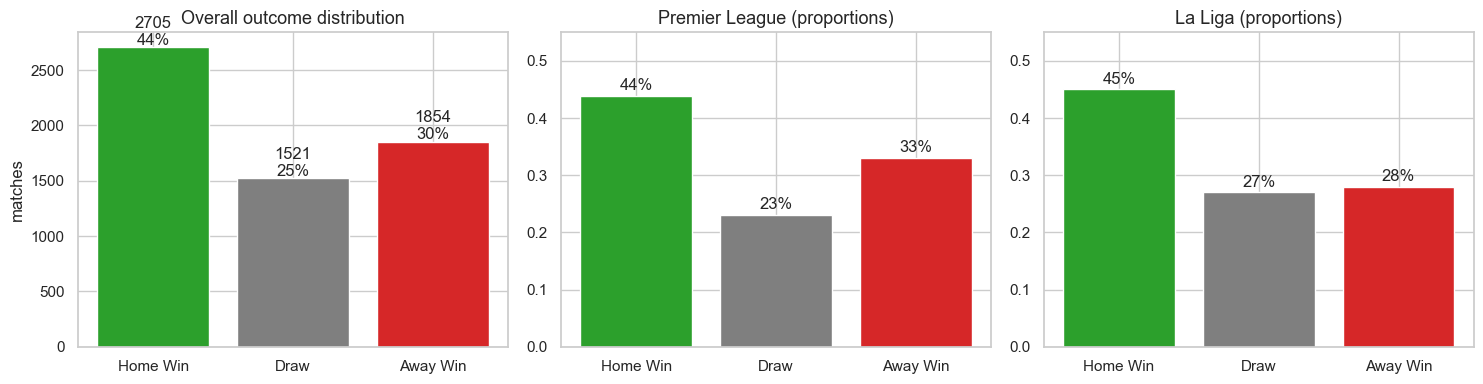

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = ["H", "D", "A"]
# overall
counts = df["FTR"].value_counts().reindex(order)
axes[0].bar([RESULT_LABEL[o] for o in order], counts.values,
            color=["#2ca02c", "#7f7f7f", "#d62728"])
axes[0].set_title("Overall outcome distribution")
axes[0].set_ylabel("matches")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f"{v}\n{v/len(df):.0%}", ha="center")

# per league
for ax, lg in zip(axes[1:], ["epl", "laliga"]):
    sub = df[df["League"] == lg]
    c = sub["FTR"].value_counts(normalize=True).reindex(order)
    ax.bar([RESULT_LABEL[o] for o in order], c.values,
           color=["#2ca02c", "#7f7f7f", "#d62728"])
    ax.set_title(f"{LEAGUE_LABEL[lg]} (proportions)")
    ax.set_ylim(0, 0.55)
    for i, v in enumerate(c.values):
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center")

plt.tight_layout(); plt.show()

In [7]:
# Numeric table: outcome proportions per league
prop = (df.groupby("League")["FTR"].value_counts(normalize=True)
          .unstack()[order].rename(columns=RESULT_LABEL))
prop.index = prop.index.map(LEAGUE_LABEL)
prop.round(3)

FTR,Home Win,Draw,Away Win
League,,,
Premier League,0.439,0.23,0.33
La Liga,0.450,0.27,0.28


**Reading it:** Home wins are the single most common outcome in both leagues — that is the *home advantage*. The **Draw** class is the smallest (~22-25%), which is exactly why it will be the hardest for the models and why we report F1 / per-class recall, not just accuracy. A naive model that always predicts "Home Win" would already get the home-win share right — that is our **baseline to beat**.

## 4. Home Advantage

In [8]:
home_win_rate = df.groupby("LeagueName").apply(
    lambda g: pd.Series({
        "Home win %": (g["FTR"] == "H").mean(),
        "Draw %":     (g["FTR"] == "D").mean(),
        "Away win %":  (g["FTR"] == "A").mean(),
        "Avg home goals": g["FTHG"].mean(),
        "Avg away goals": g["FTAG"].mean(),
    }), include_groups=False)
home_win_rate.round(3)

,Home win %,Draw %,Away win %,Avg home goals,Avg away goals
LeagueName,,,,,
La Liga,0.450,0.27,0.28,1.456,1.113
Premier League,0.439,0.23,0.33,1.553,1.306


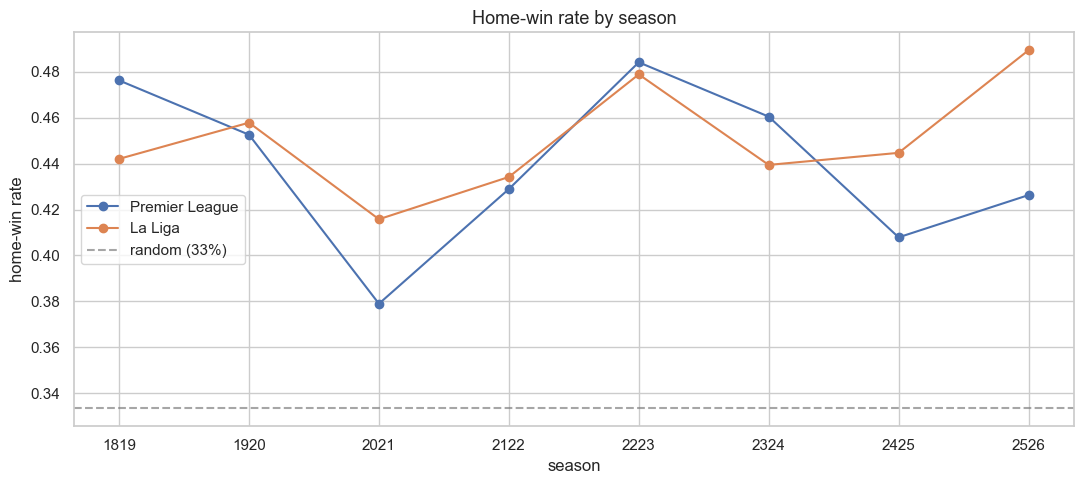

In [9]:
# Home advantage over time (per season), per league
fig, ax = plt.subplots(figsize=(11, 5))
for lg in ["epl", "laliga"]:
    sub = df[df["League"] == lg]
    rate = sub.groupby("Season").apply(lambda g: (g["FTR"] == "H").mean(),
                                       include_groups=False)
    ax.plot(rate.index, rate.values, marker="o", label=LEAGUE_LABEL[lg])
ax.axhline(1/3, ls="--", color="grey", alpha=.7, label="random (33%)")
ax.set_title("Home-win rate by season")
ax.set_ylabel("home-win rate"); ax.set_xlabel("season"); ax.legend()
plt.tight_layout(); plt.show()

> **Note the 2020/21 dip** — that's the COVID season played behind closed doors (no crowds). Home advantage visibly weakened. A nice real-world detail to mention in the report.

## 5. Goals

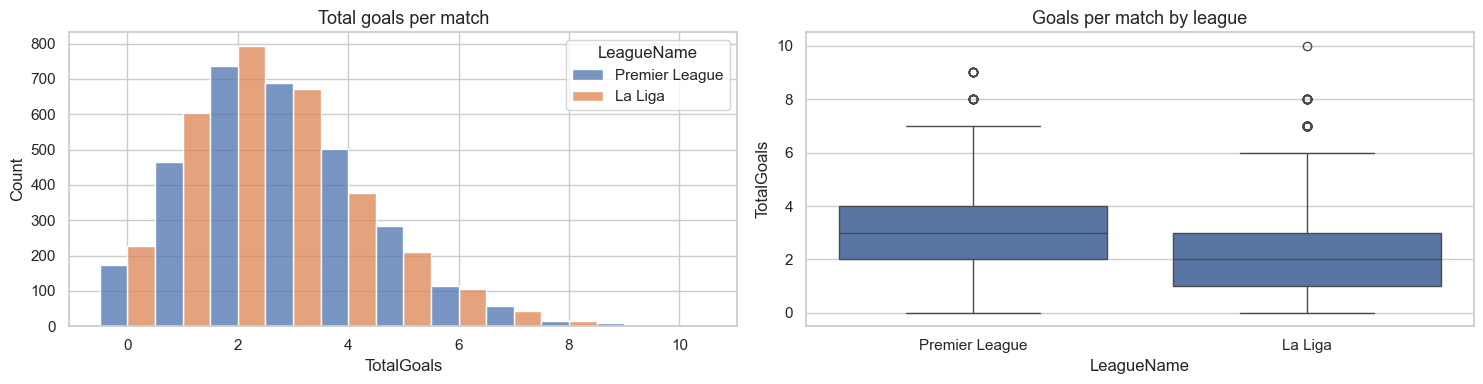

                mean  50%   max
LeagueName                     
La Liga         2.57  2.0  10.0
Premier League  2.86  3.0   9.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df["TotalGoals"] = df["FTHG"] + df["FTAG"]

sns.histplot(data=df, x="TotalGoals", hue="LeagueName", multiple="dodge",
             discrete=True, ax=axes[0])
axes[0].set_title("Total goals per match")

sns.boxplot(data=df, x="LeagueName", y="TotalGoals", ax=axes[1])
axes[1].set_title("Goals per match by league")
plt.tight_layout(); plt.show()

print(df.groupby("LeagueName")["TotalGoals"].describe()[["mean", "50%", "max"]].round(2))

## 6. Expected Goals (xG) — the key modern feature

xG measures *chance quality*, not just the scoreline. Two questions matter for modeling:
1. Does xG track actual goals? (sanity)
2. Does the **xG difference** (home xG − away xG) separate the three outcomes? (predictive power)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17248\3640136393.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="FTR", y="xG_diff", order=order,
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17248\3640136393.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([RESULT_LABEL[o] for o in order])


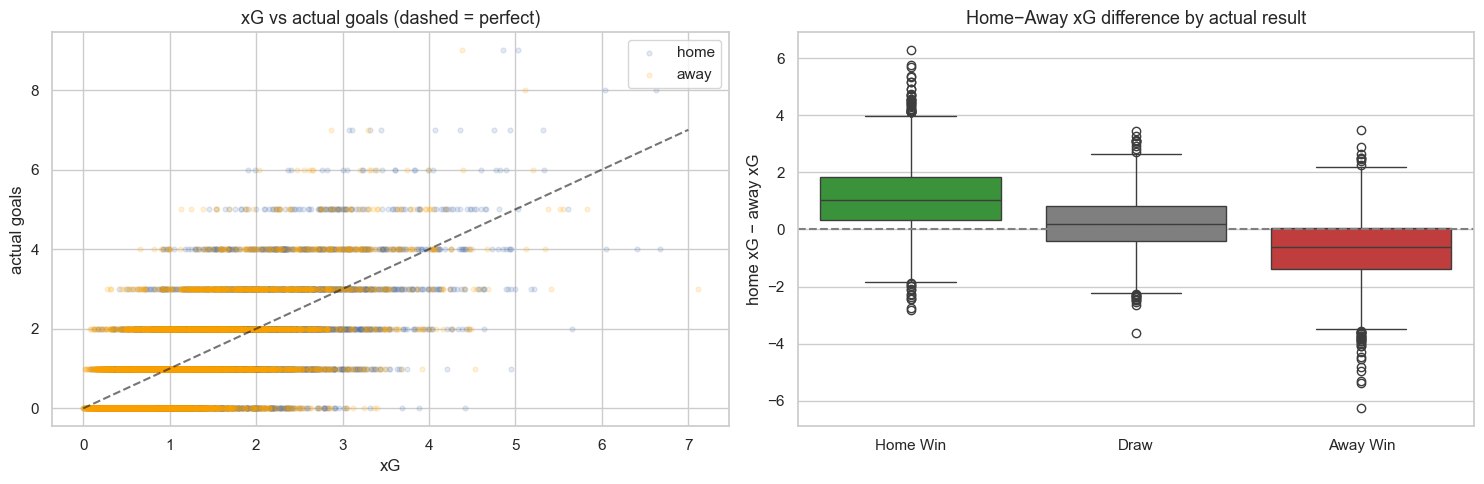

In [11]:
df["xG_diff"] = df["home_xG"] - df["away_xG"]
df["goal_diff"] = df["FTHG"] - df["FTAG"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# xG vs actual goals
axes[0].scatter(df["home_xG"], df["FTHG"], alpha=.15, s=12, label="home")
axes[0].scatter(df["away_xG"], df["FTAG"], alpha=.15, s=12, label="away", color="orange")
lims = [0, 7]; axes[0].plot(lims, lims, "k--", alpha=.6)
axes[0].set_xlabel("xG"); axes[0].set_ylabel("actual goals")
axes[0].set_title("xG vs actual goals (dashed = perfect)"); axes[0].legend()

# xG diff by outcome
sns.boxplot(data=df, x="FTR", y="xG_diff", order=order,
            ax=axes[1], palette=["#2ca02c", "#7f7f7f", "#d62728"])
axes[1].set_xticklabels([RESULT_LABEL[o] for o in order])
axes[1].axhline(0, color="grey", ls="--")
axes[1].set_title("Home−Away xG difference by actual result")
axes[1].set_xlabel(""); axes[1].set_ylabel("home xG − away xG")
plt.tight_layout(); plt.show()

**Reading it:** xG diff cleanly separates outcomes — home wins cluster at positive xG diff, away wins at negative, draws near zero. That overlap in the middle is exactly the hard zone where draws live. This is strong evidence xG-based features will help the models.

## 7. Bookmaker Odds → Implied Probability

Odds encode the market's probability. We convert and **de-vig** (remove the bookmaker margin) so the three probabilities sum to 1.

`implied = 1 / odds`, then divide each by their sum (the *overround*).

In [12]:
def implied_probs(h, d, a):
    """De-vig 3-way odds into probabilities that sum to 1."""
    rh, rd, ra = 1/h, 1/d, 1/a
    s = rh + rd + ra            # overround (>1 = bookmaker margin)
    return rh/s, rd/s, ra/s, s

# Use Bet365 (present for every match)
ph, pdr, pa, over = implied_probs(df["B365H"], df["B365D"], df["B365A"])
df["mkt_p_home"] = ph; df["mkt_p_draw"] = pdr; df["mkt_p_away"] = pa
df["overround"] = over
df["margin"] = over - 1

print("Bookmaker margin (Bet365):")
print(df.groupby("LeagueName")["margin"].mean().round(4).apply(lambda x: f"{x:.2%}"))

Bookmaker margin (Bet365):
LeagueName
La Liga           5.49%
Premier League    5.10%
Name: margin, dtype: object


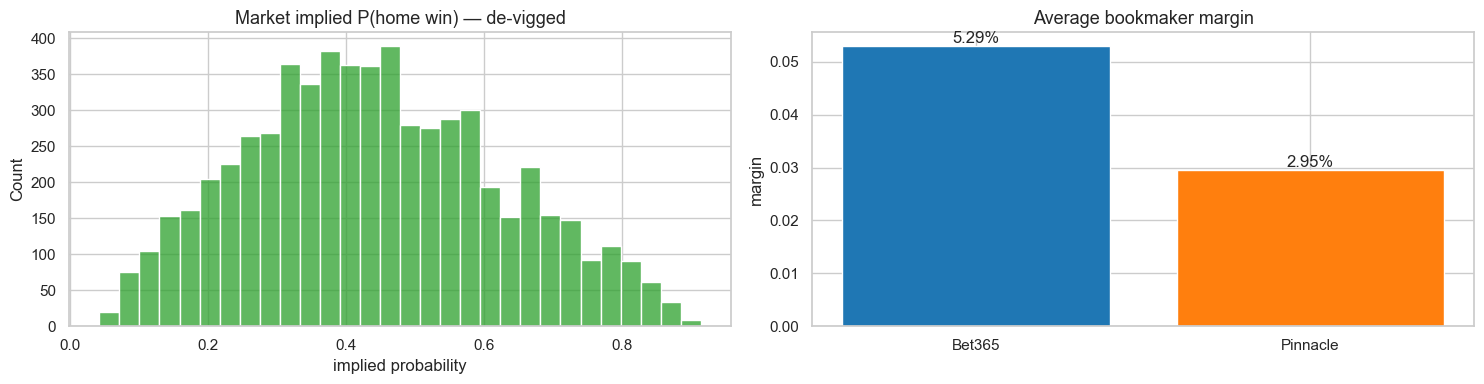

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(df["mkt_p_home"], bins=30, ax=axes[0], color="#2ca02c")
axes[0].set_title("Market implied P(home win) — de-vigged")
axes[0].set_xlabel("implied probability")

# Pinnacle margin vs Bet365 margin (Pinnacle is sharper -> lower margin)
ph2, pd2, pa2, over_ps = implied_probs(df["PSH"], df["PSD"], df["PSA"])
comp = pd.DataFrame({
    "Bet365": df["margin"],
    "Pinnacle": over_ps - 1,
}).mean()
axes[1].bar(comp.index, comp.values, color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Average bookmaker margin")
axes[1].set_ylabel("margin");
for i, v in enumerate(comp.values):
    axes[1].text(i, v, f"{v:.2%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Reading it:** Pinnacle's margin is visibly lower than Bet365's — that's *why* Pinnacle's prices are the "sharp" benchmark we'll use to judge whether our models beat the market. The lower the margin, the closer the odds are to true probability.

## 8. Is the Market Well-Calibrated? (the bar our models must clear)

If we bucket matches by the market's implied P(home win), the actual home-win rate in each bucket should track the diagonal. This is the benchmark: **the bookmaker is extremely well-calibrated**, and our models will be compared against exactly this.

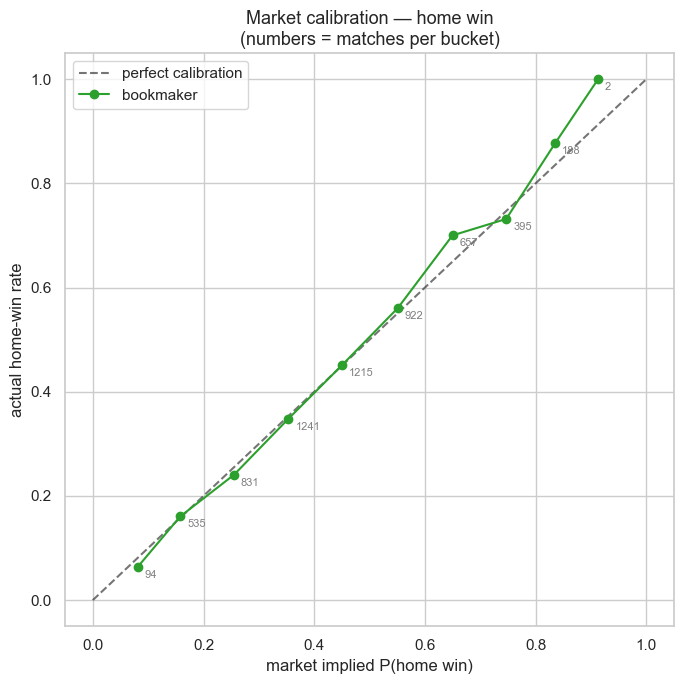

In [14]:
bins = np.linspace(0, 1, 11)
df["p_bucket"] = pd.cut(df["mkt_p_home"], bins)
cal = df.groupby("p_bucket", observed=True).agg(
    predicted=("mkt_p_home", "mean"),
    actual=("FTR", lambda s: (s == "H").mean()),
    n=("FTR", "size"),
).dropna()

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", alpha=.6, label="perfect calibration")
ax.plot(cal["predicted"], cal["actual"], "o-", color="#2ca02c", label="bookmaker")
for _, r in cal.iterrows():
    ax.annotate(int(r["n"]), (r["predicted"], r["actual"]),
                textcoords="offset points", xytext=(5, -8), fontsize=8, color="grey")
ax.set_xlabel("market implied P(home win)"); ax.set_ylabel("actual home-win rate")
ax.set_title("Market calibration — home win\n(numbers = matches per bucket)")
ax.legend(); plt.tight_layout(); plt.show()

## 9. How Often Does the Favorite Win? — the naive baseline

The simplest possible predictor: pick whichever outcome the bookmaker makes most likely. Our ML models **must beat this** to be worth anything.

In [15]:
def fav_pick(row):
    probs = {"H": row["mkt_p_home"], "D": row["mkt_p_draw"], "A": row["mkt_p_away"]}
    return max(probs, key=probs.get)

df["fav"] = df.apply(fav_pick, axis=1)
df["fav_correct"] = df["fav"] == df["FTR"]

base = df.groupby("LeagueName")["fav_correct"].mean()
print("Bookmaker-favorite accuracy (our baseline to beat):")
for lg, acc in base.items():
    print(f"  {lg:16s}: {acc:.1%}")
print(f"  {'OVERALL':16s}: {df['fav_correct'].mean():.1%}")

# also: how often is the favorite a draw? (almost never)
print("\nFavorite pick distribution:")
print(df["fav"].value_counts(normalize=True).rename(RESULT_LABEL).round(3))

Bookmaker-favorite accuracy (our baseline to beat):
  La Liga         : 53.1%
  Premier League  : 55.0%
  OVERALL         : 54.0%

Favorite pick distribution:
fav
Home Win    0.661
Away Win    0.339
Draw        0.001
Name: proportion, dtype: float64


**This is a critical number.** Notice the favorite is *almost never* a draw — bookmakers rarely make the draw the most likely outcome, so this naive baseline essentially never predicts draws. If our models can correctly catch some draws *without* hurting overall accuracy, that's a genuine win. The per-league baseline difference is our first concrete hint about which league is more predictable.

## 10. Feature Correlations

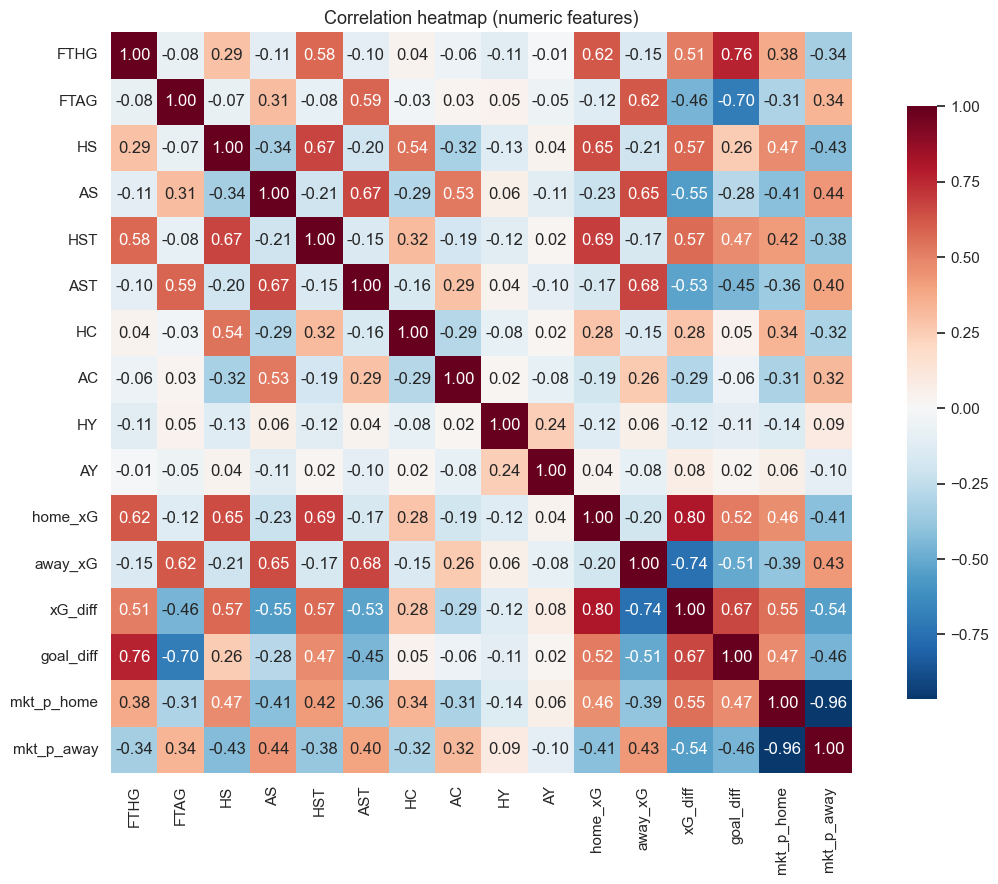

In [16]:
num_cols = ["FTHG", "FTAG", "HS", "AS", "HST", "AST", "HC", "AC",
            "HY", "AY", "home_xG", "away_xG", "xG_diff", "goal_diff",
            "mkt_p_home", "mkt_p_away"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.show()

**Reading it:** `xG_diff`, `mkt_p_home`, shots-on-target difference and `goal_diff` are the features most correlated with the outcome — these will likely be the strongest predictors. Note how `mkt_p_home` and `xG_diff` are themselves correlated: the market already "knows" about chance quality, so they carry overlapping information.

## 11. EPL vs La Liga — Predictability Summary

Pulling the league comparison together. The hypothesis: La Liga is **more predictable** (a few dominant clubs), so the bookmaker baseline — and later our models — should score higher there. Higher accuracy on La Liga would reflect the *league*, not a better model.

In [17]:
summary = df.groupby("LeagueName").agg(
    home_win_rate=("FTR", lambda s: (s == "H").mean()),
    draw_rate=("FTR", lambda s: (s == "D").mean()),
    avg_goals=("TotalGoals", "mean"),
    favorite_accuracy=("fav_correct", "mean"),
    avg_margin=("margin", "mean"),
).round(3)
summary

,home_win_rate,draw_rate,avg_goals,favorite_accuracy,avg_margin
LeagueName,,,,,
La Liga,0.450,0.27,2.568,0.531,0.055
Premier League,0.439,0.23,2.859,0.550,0.051


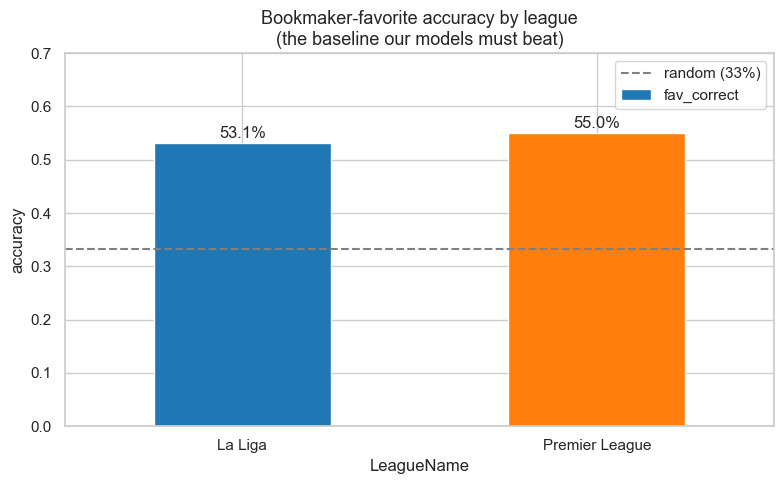

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
base.plot(kind="bar", color=["#1f77b4", "#ff7f0e"], ax=ax)
ax.set_title("Bookmaker-favorite accuracy by league\n(the baseline our models must beat)")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 0.7)
ax.axhline(1/3, ls="--", color="grey", label="random (33%)")
for i, v in enumerate(base.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.legend(); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 12. Key Takeaways

1. **Balanced-ish 3-class target**, but **Draw is the minority** (~22-25%) — accuracy alone is misleading; we'll lean on F1 and per-class recall.
2. **Home advantage is real** in both leagues (home win is the modal outcome), and visibly **dropped in the empty-stadium 2020/21 COVID season**.
3. **xG difference cleanly separates outcomes** — strong signal that xG features will help; the overlap zone is where draws live (the hard part).
4. **The market is sharply calibrated** and **Pinnacle's margin is lower than Bet365's** — Pinnacle is our sharp benchmark for the betting simulation.
5. **The bookmaker favorite almost never picks a draw** — catching draws without losing accuracy is where a good model can add value.
6. **Baseline to beat** = bookmaker-favorite accuracy per league. Any model below this line is not learning anything useful.
7. **League difference** sets up the per-league model comparison: differences in accuracy will largely reflect each league's *predictability*, not just model quality.

**Next step (Step 3): Feature Engineering** — rolling form, rolling xG, head-to-head, rest days, and the market-derived features, all built with strict time-ordering to avoid leakage.
